# Project n°3 : Vision Transformers vs. Convolutional Neural Networks

**Authors** : Selim Ben Abdallah¹, Paola De Truchis¹, Eduardo De Jesus Zancanaro Garcia¹, and Edda Iveland¹ \
¹ INSA Toulouse

The goal of this project is to compare the performance of vision transformers (ViTs) to convolutional neural networks (CNNs) on the task of image classification on labelled datasets.

---
---

**Our notebook is structured as follows :**

1. **Presentation of the datasets**
- CIFAR-10
- Food-101 ?

2. **Convolution Neural Networks**
- Custom CNN, ResNet-18

3. **Vision Transformers**
- ViT-Tiny, Swin-Tiny

4. **Comparison**

5. **Conclusion**


---
---

In [ ]:
import tqdm
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt

# utils
import importlib
import utils.utils_dataset as uds
import utils.utils_images as uimg
#import utils.utils_dataset_instance as udi
#import utils.utils_dataset_transform_segmentation as udts
import utils.utils_classification_metrics as ucm
import utils.utils_train_evaluate as ute
import utils.utils_drive as udt
#import utils.utils_segmentation as utseg

importlib.reload(uds)
importlib.reload(uimg)
#importlib.reload(udi)
#importlib.reload(udts)
importlib.reload(ucm)
importlib.reload(ute)
importlib.reload(udt)
#importlib.reload(utseg)

from utils.utils_dataset import parse_xml, count_files
#from utils.utils_dataset_instance import PetDataset
from utils.utils_images import show_image_mask_bbox, show_9_samples, show_random_classif_predictions_topk, show_random_classif_predictions,visualize_segmentation_predictions, study_most_confused_breeds, plot_misclassified_pair, visualize_topk_by_metric
from utils.utils_dataset_transform_segmentation import seg_train_transform, seg_val_transform
from utils.utils_classification_metrics import plot_train_val_loss, plot_pr_curve, plot_roc_curve, plot_confusion_matrix, plot_accuracy, classification_metrics_multiclass
from utils.utils_train_evaluate import train_one_epoch, train_one_epoch_for_pretrained, evaluate, evaluate_multiclass, save_model_and_results, load_model_and_results
#from utils.utils_train_evaluate import train_one_epoch_segmentation, evaluate_segmentation, save_segmentation_experiment, load_segmentation_experiment
from utils.utils_drive import download_gdrive_folder
from utils.utils_segmentation import DiceLoss, combined_loss, plot_dice_iou, compute_per_image_metrics_seg, join_metrics_with_test_df, summarize_group, filter_species, plot_metric_by_species_row

# models
import models.models_project_3 as mp3
importlib.reload(mp3)
from models.models_project_3 import CNN_Binary, ResNet18_Binary, CNN_Multiclass, VGG16_Multiclass, UNet, UNetPP

# Sklearn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T



ModuleNotFoundError: No module named 'utils'

In [ ]:
#make requirements.txt!

# Brainstorming

**Models**
- Custom CNN
- ResNet-18
- ViT-Tiny/16 (patch size : 16, embed dim : 192, depth : 12, heads : 3) (smaller than ViT B-16)
- Swin-T (Swin Tiny)

**Datasets**
- CIFAR-10 : 60k images, 32x32, 10 classes (50k train / 10k test)
- Food-101 : 101k images, 101 classes (750 train + 250 test per class, noisy training set)
- Important : For ImageNet-pretrained fine-tuning: resize/crop inputs to 224×224 for ResNet/ViT/Swin (and ideally also for the custom CNN for fair time/memory comparison)

**Comparison protocol/metrics**
- For each dataset/training, we can report
- Top-1 accuracy (maybe macro-f1 if classes are imbalanced)
- Training time
- Inference latency (ms/image at batch=1 and batch=32)
- Nb of parameters
- Peak GPU memory during training and during inference ?


**Training settings**
- Train from scratch on CIFAR-10 (4 from-scratch trainings)
- Fine-tune ImageNet-1K pretrained weights on CIFAR-10 (resized) and Food-101 (8 fine-tunings)
- 12 full trainings in total

| Dataset | Type | Custom CNN | ResNet-18 | ViT-Tiny | Swin-T |
|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | From Scratch | 32 | 32 (CIFAR stem*) | 32 (patch=4**) | 32 (patch=4, window=4***) |
| CIFAR-10 | Fine-Tune (ImageNet-1k) | 224 | 224 | 224 | 224 |
| Food-101 | Fine-Tune (ImageNet-1k) | 224 | 224 | 224 | 224 |

- *ResNet-18 CIFAR stem: conv3×3 stride1, no maxpool, otherwise it downsamples too aggressively at 32×32.
- **ViT at 32×32: patch=16 is not viable (only 4 tokens). Use patch=4 so you get 8×8=64 tokens.
- ***Swin at 32×32: use patch=4 (8×8 tokens) and a smaller window size (e.g., 4) so windows make sense.

In [ ]:
#Add function for validating dataset structure

## 1 - Datasets

The CIFAR-10 dataset contains 60000 labelled images of 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. The images are coloured and of size 32x32, so the **images are not too big**. This makes training processes quicker. As the dataset is neither too big nor too small, we hope that differences in performance between CNNs and ViTs will not be due to the dataset scale, but rather the models themselves. 

We will we defining the ViT and CNN **from scratch**, so using a dataset that is easier to train from scratch is essential. If we were to use a dataset with larger images, pretrained weights would have yielded higher performance, making it harder to compare models from scratch. 

Each class in the CIFAR-10 dataset contains the **same number of images** and labels are clear and distinguished. Consequently, differences between CNNs and ViTs will not be due to class imbalances or noisy annotations. 

Additionally, CIFAR-10 has been **extensively studied**, aiding the comparison we will perform at the end of this project to the literature. 

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

### 1.1 Dataset construction

In [ ]:
 # cifar-10 normaisation -> 
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std  = (0.2470, 0.2435, 0.2616)
#imagenet
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

train_transform_cifar_32 = transforms.Compose([
    # augmentation on training set 
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

test_transform_cifar_32 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

train_transform_cifar_224 = transforms.Compose([
    # augmentation on training set 
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform_cifar_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


In [18]:
train_cifar10_32 = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar-10/cifar32",
    train=True,
    download=False,
    transform=train_transform_cifar_32
)

test_cifar10_32 = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar-10/cifar32",
    train=False,
    download=False,
    transform=test_transform_cifar_32
)

train_cifar10_224 = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar-10/cifar224",
    train=True,
    download=False,
    transform=train_transform_cifar_224
)

test_cifar10_224 = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar-10/cifar224",
    train=False,
    download=False,
    transform=test_transform_cifar_224
)

In [19]:
print("The classes of the cifar10 dataset are:")
cifar_class_names = train_cifar10_32.classes
print(cifar_class_names)
print("---------------------")
cifar_num_classes = len(train_cifar10_32.classes)
print("There are",cifar_num_classes, "classes")

The classes of the cifar10 dataset are:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
---------------------
There are 10 classes


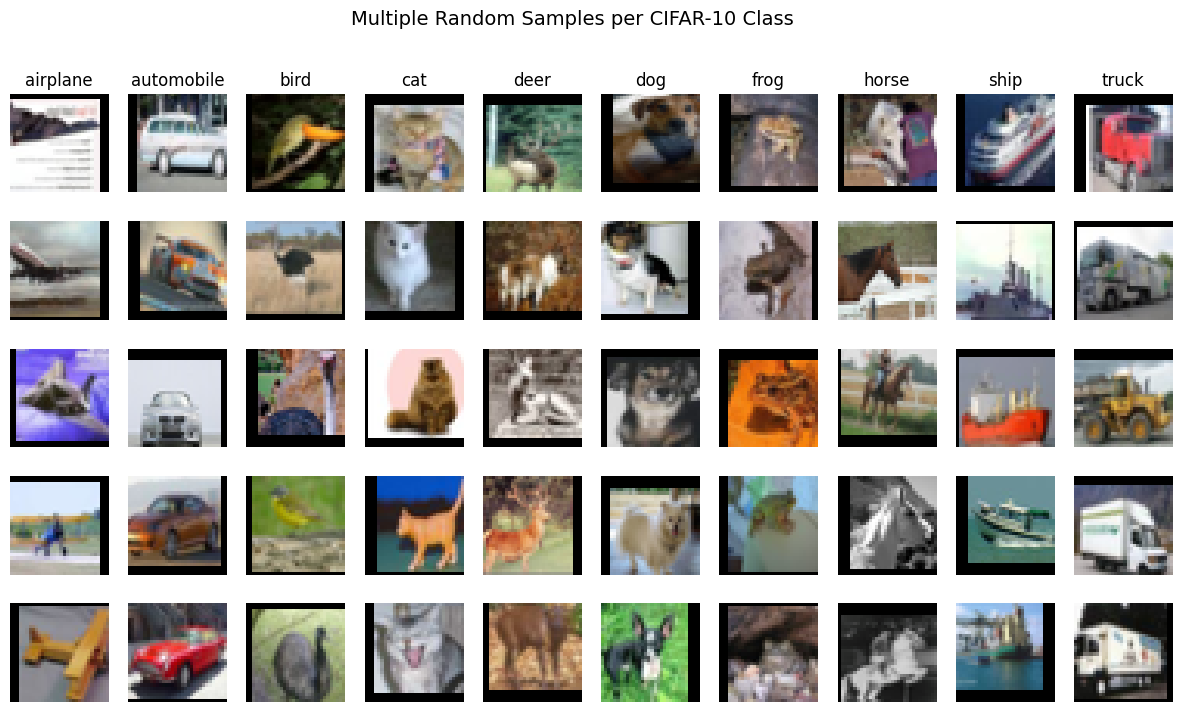

In [26]:
cifar_mean = torch.tensor([0.4914, 0.4822, 0.4465])
cifar_std  = torch.tensor([0.2470, 0.2435, 0.2616])

# printing images of the cifar-10 dataset
num_samples = 5
plt.figure(figsize=(15, 8))

for cls in range(cifar_num_classes):
    indices = np.where(np.array(train_cifar10_32.targets) == cls)[0]
    chosen = np.random.choice(indices, num_samples, replace=False)

    for j, idx in enumerate(chosen):
        img, label = train_cifar10_32[idx]
        if torch.is_tensor(img):
            img = img * cifar_std[:, None, None] + cifar_mean[:, None, None]
            img = img.clamp(0, 1)                  
            img = img.permute(1, 2, 0).cpu().numpy()

        plt.subplot(num_samples, cifar_num_classes,
                    cls + j * cifar_num_classes + 1)
        plt.imshow(img)
        plt.axis("off")

        if j == 0:
            plt.title(cifar_class_names[cls])

plt.suptitle("Multiple Random Samples per CIFAR-10 Class", fontsize=14)
plt.show()

In [ ]:
#make validation set
train_cifar10_32, val_cifar10_32 = train_test_split(
    train_cifar10_32,
    test_size=0.2,  # 1000 images for validation
    random_state=42,     
)

train_cifar10_224, val_cifar10_224 = train_test_split(
    train_cifar10_224,
    test_size=0.2,  # 1000 images for validation
    random_state=42,     
)

In [ ]:
#check
print("There are", len(train_cifar10_32), "images in the train set")
print("There are", len(test_cifar10_32), "images in the validation set")
print("There are", len(val_cifar10_32), "images in the test set")

There are 40000 images in the train set
There are 10000 images in the validation set
There are 10000 images in the test set


In [ ]:
batch_size = 32 
num_workers = 0 

In [ ]:
train_loader_cifar_32 = DataLoader(train_cifar10_32, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader_cifar_32 = DataLoader(val_cifar10_32,   batch_size=batch_size, shuffle=False, num_workers=num_workers)

train_loader_cifar_224 = DataLoader(train_cifar10_224, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader_cifar_224 = DataLoader(val_cifar10_224,   batch_size=batch_size, shuffle=False, num_workers=num_workers)

## 2 - Convolutional Neural Networks

### 2.1 - Custom CNN

### 2.2 - ResNet-18

## 3 - Vision Transformers

### 3.1 - VisionTransformer-Tiny (ViT-Tiny)

### 3.2 - Swin Transformer-Tiny (Swin-Tiny)